<a href="https://colab.research.google.com/github/yasodharani-10-26/Everglow-studio/blob/main/day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

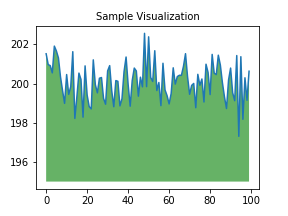

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

In [1]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Iris.csv"

# Load the latest version
iris = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "saurabh00007/iriscsv",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", iris.head())

/tmp/ipykernel_1861/4044370883.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  iris = kagglehub.load_dataset(


Using Colab cache for faster access to the 'iriscsv' dataset.
First 5 records:    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [2]:
iris["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


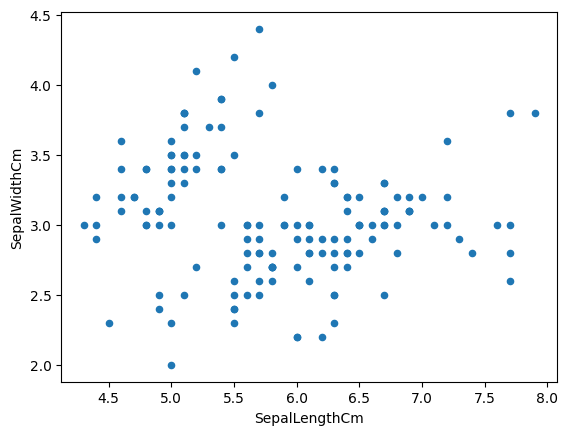

In [3]:
iris.plot(kind="scatter",x="SepalLengthCm",y="SepalWidthCm")
plt.show()

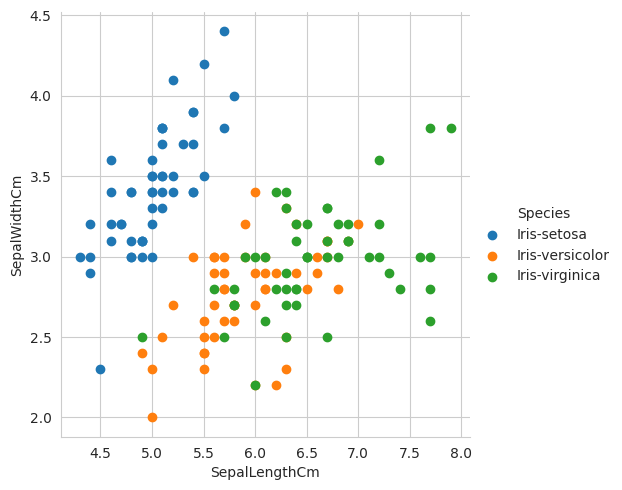

In [4]:
sns.set_style("whitegrid")
sns.FacetGrid(iris,hue="Species",height=5)\
.map(plt.scatter,"SepalLengthCm","SepalWidthCm")\
.add_legend()
plt.show()

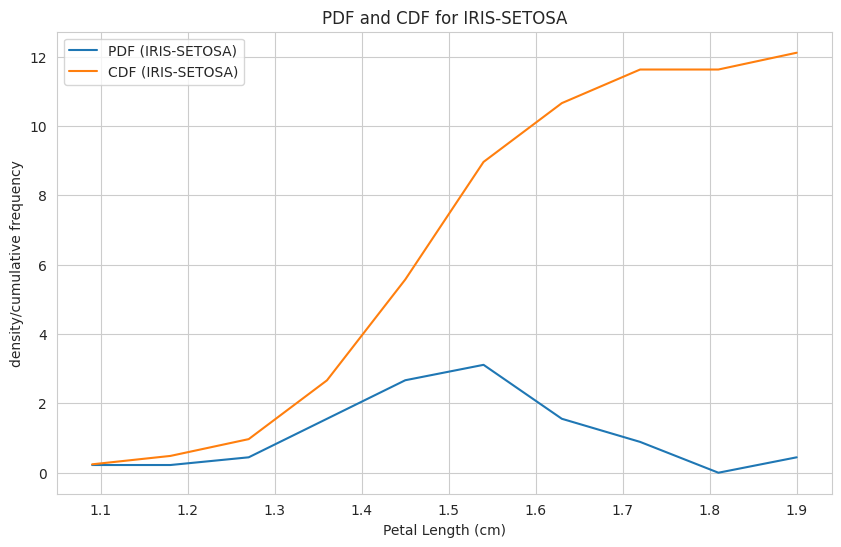

In [6]:
import numpy as np
df_setosa = iris.loc[iris["Species"] == "Iris-setosa"]
counts_setosa,bin_edges_setosa=np.histogram(df_setosa['PetalLengthCm'],bins=10,density=True)
cdf_setosa=np.cumsum(counts_setosa*(bin_edges_setosa[1]*bin_edges_setosa[0]))
plt.figure(figsize=(10,6))
plt.plot(bin_edges_setosa[1:],counts_setosa,label="PDF (IRIS-SETOSA)")
plt.plot(bin_edges_setosa[1:],cdf_setosa,label="CDF (IRIS-SETOSA)")
plt.title('PDF and CDF for IRIS-SETOSA')
plt.xlabel('Petal Length (cm)')
plt.ylabel('density/cumulative frequency')
plt.legend()
plt.show()

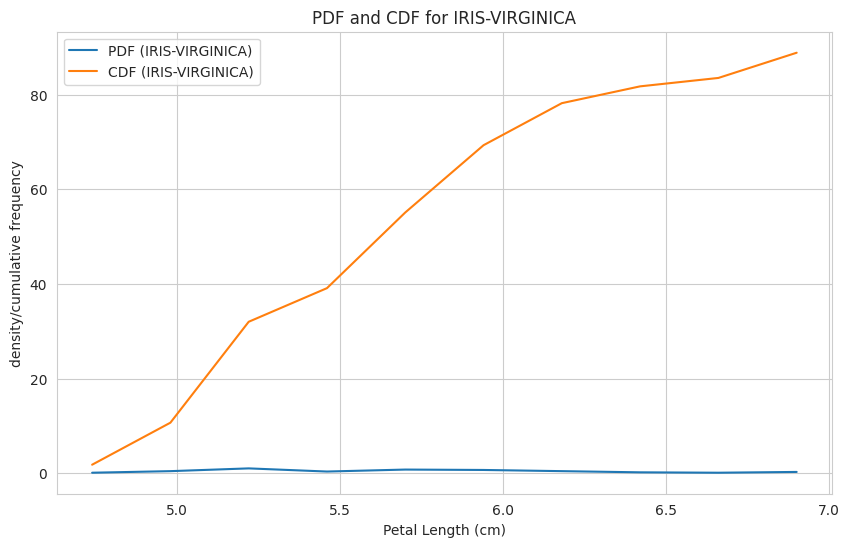

In [8]:
df_virginica = iris.loc[iris["Species"] == "Iris-virginica"]
counts_virginica,bin_edges_virginica=np.histogram(df_virginica['PetalLengthCm'],bins=10,density=True)
cdf_virginica=np.cumsum(counts_virginica*(bin_edges_virginica[1]*bin_edges_virginica[0]))
plt.figure(figsize=(10,6))
plt.plot(bin_edges_virginica[1:],counts_virginica,label="PDF (IRIS-VIRGINICA)")
plt.plot(bin_edges_virginica[1:],cdf_virginica,label="CDF (IRIS-VIRGINICA)")
plt.title('PDF and CDF for IRIS-VIRGINICA')
plt.xlabel('Petal Length (cm)')
plt.ylabel('density/cumulative frequency')
plt.legend()
plt.show()

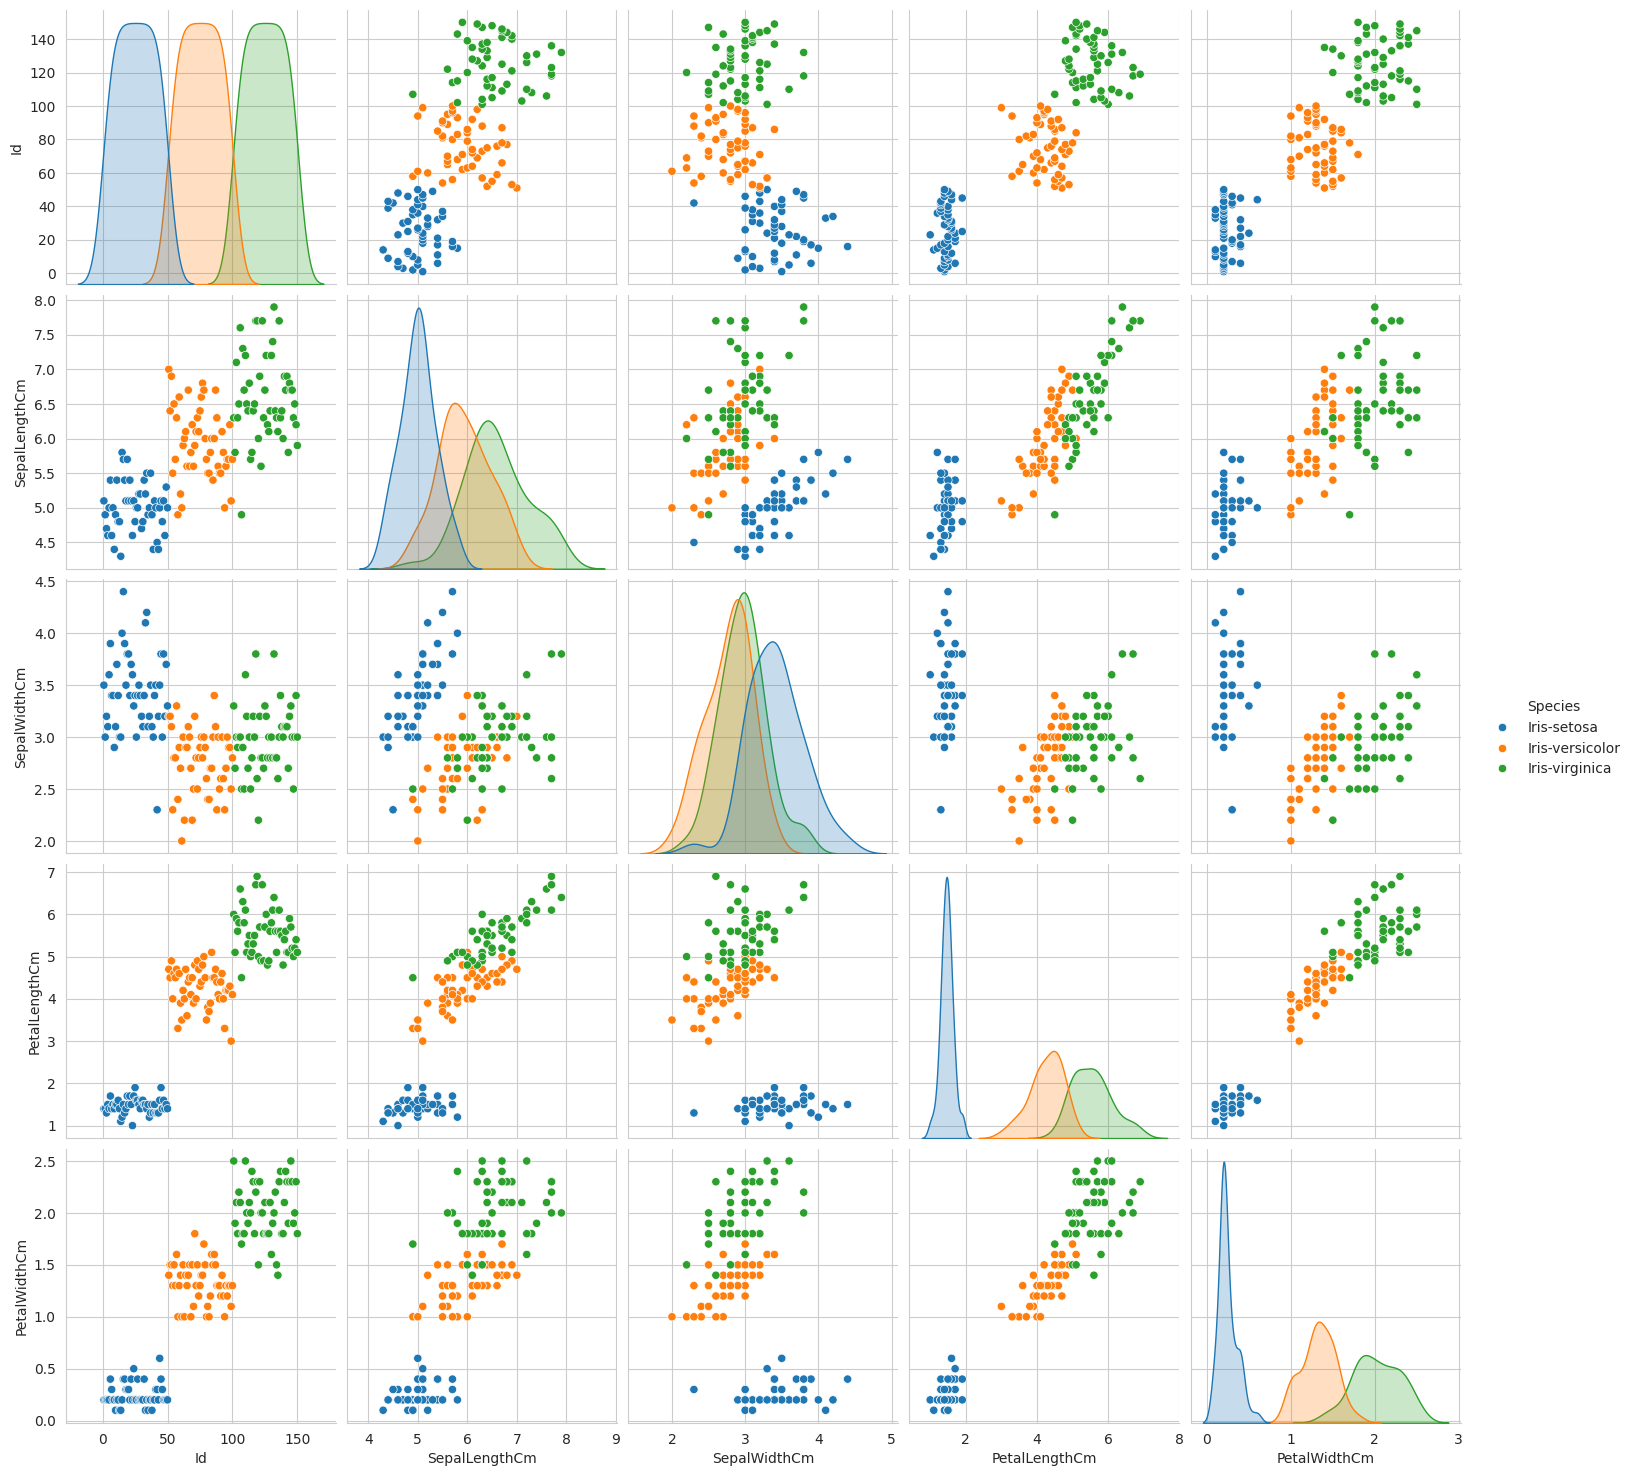

In [10]:
plt.close()
sns.set_style("whitegrid")
sns.pairplot(iris,hue="Species",height=3)
plt.show()

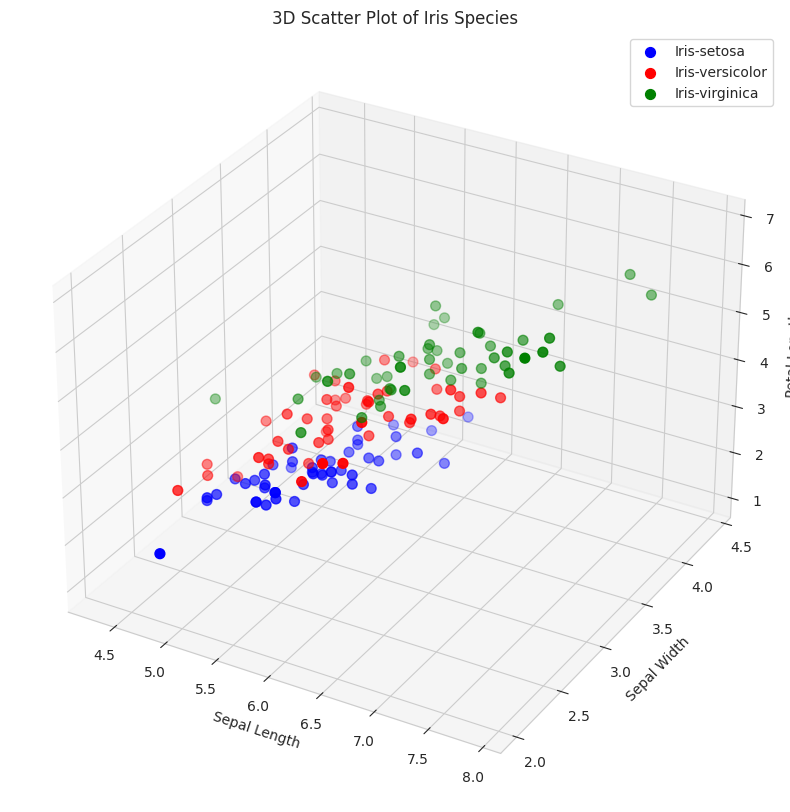

In [12]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(figsize=(12,10))
ax=fig.add_subplot(111,projection="3d")
species_names=iris['Species'].unique()
colors=['b','r','g']
for i, species_name in enumerate(species_names):
  species_data=iris[iris['Species']==species_name]
  ax.scatter(species_data['SepalLengthCm'],species_data['SepalWidthCm'],species_data['PetalLengthCm'],c=colors[i],label=species_name,s=50)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Species')
ax.legend()
plt.show()

In [14]:
!kaggle kernels pull rushabhwadkar/eda-haberman-s-cancer-survival-dataset

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


### Kaggle API Authentication in Colab

1.  **Download `kaggle.json`**: Go to your Kaggle account settings (`https://www.kaggle.com/<YOUR_USERNAME>/account`). Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file to your computer.

2.  **Upload `kaggle.json` to Colab**: Click the folder icon on the left sidebar in Colab (File Browser). Then, click the 'Upload to session storage' icon (looks like an upward arrow) and select the `kaggle.json` file you just downloaded.

In [16]:
# 3. Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# 4. Move the uploaded kaggle.json file to the .kaggle directory
#    Make sure the uploaded file is named 'kaggle.json' and is in the /content/ directory (default upload location)

import os

if os.path.exists('kaggle.json'):
    !mv kaggle.json ~/.kaggle/
    # 5. Set appropriate permissions for the kaggle.json file
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API key has been set up successfully!")
else:
    print("Error: kaggle.json not found. Please upload it to your Colab session.")
    print("You can do this by clicking the folder icon on the left sidebar, then the 'Upload to session storage' icon (upward arrow), and selecting your kaggle.json file.")

Error: kaggle.json not found. Please upload it to your Colab session.
You can do this by clicking the folder icon on the left sidebar, then the 'Upload to session storage' icon (upward arrow), and selecting your kaggle.json file.


In [17]:
!ls -l /content/kaggle.json

ls: cannot access '/content/kaggle.json': No such file or directory


After running the above cell, your Kaggle API should be authenticated, and you can retry your `!kaggle` commands.